# Assignment 1 - Particle filter

- **Topic:** Designing a particle filter to estimate the position using magnetic field information

- **Assessment:** The assignment will be graded according to the rubric found on Brightspace

- **Deadline:**  27-02-2025, 17:00
- **Submitting: SUBMIT ONLY `assignment3_groupNumber.ipynb` TO BRIGHTSPACE**. 
where groupNumber is your
 group number

## Instructions
**Installation:** 
The virtual environment `venvPSF` has all the necessary packages pre-installed. Make sure to select the virtual environment when running the code. This can be done in the Jupyter notebook (in vscode) by clicking select kernel in the top right, then python environments, then myenv (python 3.11.9).

If you choose to install the virtual environment yourself, the full list of dependencies is in requirements.txt. This can be done using the steps as shown in howToInstallVirtualEnvironments.txt

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `GP.py`, `helper.py` and `linAlg.py` and the dictionary `modelParameters` as this might result in breaking the assignment.


## AI Related Policy
The use of AI is not allowed.


## Information
Please fill in your group number, names and student numbers in the cell below.



In [7]:
groupNumber = 6

STUDENT_1_NAME = "Giuliano Moroni"
STUDENT_1_STUDENT_NUMBER = "5680204"

STUDENT_2_NAME = "Ian Michel"
STUDENT_2_STUDENT_NUMBER = "6545475"

## Objectives

#### Goal

The goal of this assignment is to estimate the position $ \mathbf{p}_t $ of an agent, for $t = {1, ..., \text{T}}$ The agent moves in an indoor environment and gets information about its approximate change in position $ \Delta \mathbf{p}_t $ at every time-step. To model this, you may assume a linear dynamic model of the form:
$$\mathbf{p}_{t + 1} = \mathbf{p}_t + \Delta \mathbf{p}_{t+1} + \mathbf{w}_{t+1}$$

Where:

- $\mathbf{p}_t$ is a 3-dimensional position vector of the agent at time $t$. 

- $\Delta \mathbf{p}_t$ is the change in positon.

- $\mathbf{w}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{Q})$ is Gaussian white noise.

- $ \mathbf{Q} \in \mathbb{R}^{3 \times 3} $ is the covariance of the process noise.

Since the information of the change in position $ \Delta \mathbf{p}_t$ contains errors, the position estimates from the dynamic model will drift. This means that over time, the agent will lose track of where it actually is. To remedy this, the agent is carrying a magnetometer, and has a map of the magnetic field. The magnetometer samples a measurement of the magnetic field $\mathbf{y}_t$ at every position $\mathbf{p}_t$. The map of the magnetic field is modeled by a non-linear function: a reduced rank Gaussian process (you do not need to understand, model or change the GP model, only to call the function evaluation). This results in the non-linear measurement model:
$$ \mathbf{y}_t = f(\mathbf{p}_t) + \mathbf{v}_t $$

Where:

- $\mathbf{y}_t$ is a 3-dimensional measurement vector of the magnetic field at time-step $t$.

- $f(\cdot)$ is the reduced rank Gaussian process function.

- $\mathbf{v}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{R})$ is Gaussian white noise.

- $ \mathbf{R} \in \mathbb{R}^{3 \times 3} $ is the covariance of the measurement noise.


#### First load in the data
To start, first load in the data below
All variables you will use are numpy arrays, where
- `magnetometerMeasurements` $\in \mathbb{R}^{3 \times \text{T}}$ is a numpy array containing the magnetometer measurements
- `magnetometerInitialPosition` $\in \mathbb{R}^{3 \times 1}$ is a numpy array containing the initial position of the magnetometer
- `deltaMagnetometerPositions` $\in \mathbb{R}^{3 \times \text{T}}$ is a numpy array containing the change in position of the magnetometer

#### Warning
- Additionally you are provided with a dictionary modelParameters which is used in creating magnetic field maps. DO NOT CHANGE dictionary as this might break the assignment. To create the particle filter you DO NOT need this dictionary.

In [8]:
''' DO NOT CHANGE THE CODE BELOW '''
import numpy as np
import matplotlib.pyplot as plt

import GP as GP
import linAlg as linAlg
import helper as helper
np.random.seed(groupNumber)

''' load in the data'''
(magnetometerMeasurements, 
 magnetometerInitialPosition, 
 deltaMagnetometerPositions,
 modelParameters) = helper.initializeParticleFilterAssignment(groupNumber % 29)


Below, a function is given to plot the map of the magnetic field and the ground truth position of the path taken by the agent. The agent does not know this path, it only has access to its initial position, the change in position at every time-step and the magnetometer measurements. 

Your first task it to use the agent's dynamic model to try and reconstruct the ground truth path. This is also known as dead reckoning and should be done using data stored in the variables `magnetometerInitialPosition` and `deltaMagnetometerPositions`. Save the agent's positions according to the dynamic model in the variable `deadReckoning` $\in \mathbb{R}^{3 \times \text{T}}$. Additionally, compare the magnetometer measurements with the map of the magnetic field. To achieve this, store the norm of the magnetic field at every time-step in the variable `magneticFieldNorm` $\in \mathbb{R}^{\text{T}}$.

This function should output three subfigures. Every subfigure includes the magnetic field map in the background. On the left the ground truth positions are plotted together with the dead reckoning positions. In the middle the magnetic field measurements are plotted with  the ground truth positions on top of the magnetic field map. On the right, the magnetic field measurements are plotted with  the ground truth positions over the magnetic field map.

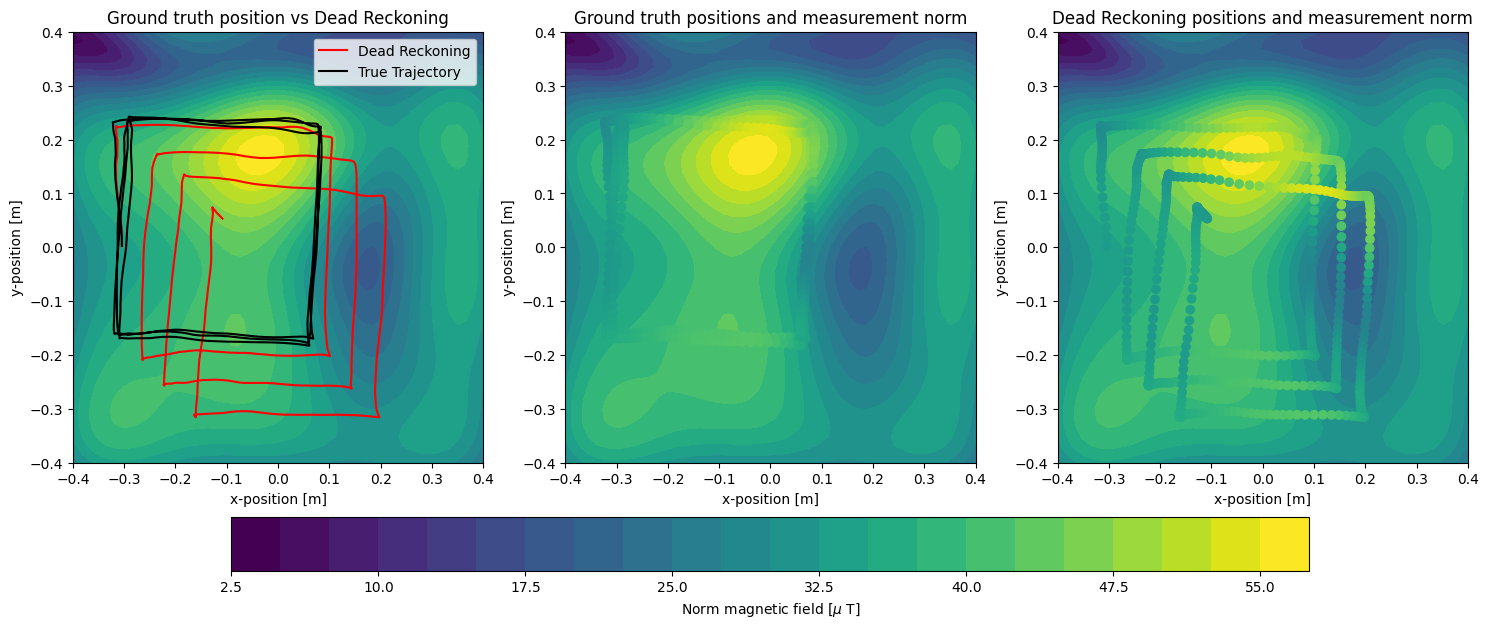

In [9]:
p = magnetometerInitialPosition.copy()
delta = deltaMagnetometerPositions.copy()
N = deltaMagnetometerPositions.shape[1]
#print(p0)
#print(deltaMagnetometerPositions)
deadReckoning = np.zeros((3,N))
for i in range(deltaMagnetometerPositions.shape[1]):
    p = (p + delta[:, i:i+1])
    deadReckoning[:,[i]] = p
# print(deadReckoning.shape[1])
# print(N)

magneticFieldNorm = (np.linalg.norm(magnetometerMeasurements, axis=0))
# print(magneticFieldNorm.shape[0])
# print(magnetometerMeasurements)
# print(magneticFieldNorm)

helper.makeInitialPositionPlots(deadReckoning, magneticFieldNorm, modelParameters)

### Discuss

Comment below on the three plots. 
- 	Does the dynamic model provide accurate enough information about the agent’s position? What will happen to the position of the agent if it moves for longer periods of time?
- Based on the magnetic field map shown in the background, explain why or why not the magnetic field is a good source of information for position estimation. 
- Explain why the measurements do or do not agree with the magnetic field map (for the middle and the right plots).


1) The dynamic model alone does not provide enough information about the agents position, this is evident from the drift of our deadreckoning trajectory. The uncertainty inherent in the proccess noise (from the dynamic mdoel) causes error accumulation in the estimated position if not accounted for, especially over longer periods of time.

2) The magnetic field is a very good source of information; we see that here, the environment has distinct areas of lower and higher magnetic field strength. As such from our magnetometer measurements, we are able to further refine our position estimate using the magnetic field map: magnetometer readings at location $(x,y)$ should correspond to the magnetic field strength at $(x,y)$. In the context of a particle filter implementation, we use the field to define the measurement likelyhood ($p(y_k|x_k^i)$). Conversely, if the magnetic field was uniform for the environment it would be an irrelevant source of information as we would not be able to relate magnetometer readings to distinguishable location alongside or dynamic model.

3) In the middle graph, since we are shown the magnetometer readings at the true location they are taken, they obviously agree with the field map (in fact, we can barely distinguish them from each other!). In the right plot, we see that the opposite is true; the dead reckoning measurement are clearly not aligned with the magnetic field. This is due to the afformentioned drift in the position estimates, the plot is comparing magnetometer measurements at the true location to a map value at the incorrect estimated location, causing the visual disagreement.  


### Particle Filter Implementation

One way to reduce the positional drift observed in the figure above, is to use magnetometer measurements. To this end, you will design a particle filter. Your task is to fill in the following three functions.

#### Task
Fill in the `dynamicUpdate()` function according to the dynamic model given above. 

#### Note:
You do not have to change the inputs and outputs to the given functions.


In [10]:

def dynamicUpdate(particlePositions, 
                  deltaPosition,
                  processCovariance,
                  Nparticles):
    
    ''' Dynamic update '''

    for n in range(Nparticles):
        # w = np.random.normal(loc=0.0, scale=processCovariance)
        # particlePositions[n] = particlePositions[n] + deltaPosition + w
        w = np.random.multivariate_normal(np.zeros(3), processCovariance)
        particlePositions[:, n] = particlePositions[:, n] + deltaPosition + w

    return particlePositions


#### Discuss

Comment on the role of the function of the dynamicUpdate in the particle filter

-->
The dynamicUpdate function handles the "propagation" of the particles as the model moves forwards: we add the position change to each particles location, and inject the stochastic process covariance noise. This causes the particles to spread out along the trajectory of the model, ready to be compared with the magnetic field and given weights in the next step.

#### Task

Fill in the `measurementUpdate()` according to the measurement model given above. 

To implement the measurement model, you will need to make predictions of the magnetic field. You DO NOT need to create this function yourself. To make predictions, use the function `GP.makeMagneticFieldPrediction(positions, modelParameters)` function make sure the input `positions` $\in \mathbb{R}^{3 \times \text{T}} $. The output should be a matrix $\in \mathbb{R}^{3 \times \text{T}}$ magnetic field predictions for every input location.

In [11]:
def measurementUpdate(particlePositions, 
                      particleWeights,
                      magnetometerMeasurement,
                      measurementCovariance,
                      Nparticles,
                      modelParameters):
    
    ''' Measurement update '''
    predictionsMagneticFieldParticles = GP.makeMagneticFieldPrediction(particlePositions, modelParameters)
    w_old = particleWeights.copy()
    det_R = np.linalg.det(measurementCovariance)
    inv_R = np.linalg.inv(measurementCovariance)

    for n in range(Nparticles):
        p_yx = (1/np.sqrt((2*np.pi)**3 * det_R)) * np.exp(-0.5*(magnetometerMeasurement[:]-predictionsMagneticFieldParticles[:, n]).T @inv_R@(magnetometerMeasurement[:]-predictionsMagneticFieldParticles[:, n]))
        particleWeights[n] = w_old[n]*p_yx
    sum_w = np.sum(particleWeights)
    particleWeights = particleWeights / sum_w


    return particlePositions, particleWeights


#### Discuss
Comment on the role of the function of the measurementUpdate in the particle filter

--> The measurementUpdate function handles the updating (and normalizing) of the weights of the particles. Due to the magnetic field model, we calculate the probability of $y$ given $f(p)$ as a gaussian with the measurement covariance. We then, for every particle, multiply this with the previous weight (bootstrap particle filturing from the lecture).


#### Task

Fill in the remainder of the `particleFilter()` function. 


In [12]:
def particleFilter(particlePositions, 
                   deltaPosition, 
                   magnetometerMeasurement, 
                   processCovariance, 
                   measurementCovariance, 
                   Nparticles,
                   modelParameters):
    ''' Estimates position based on a known map'''

    particleWeights = np.ones(Nparticles)/Nparticles ###

    if modelParameters['NtimeStepPF'] > 0:
        ''' Dynamic update '''
        particlePositions = dynamicUpdate(particlePositions, 
                                          deltaPosition, 
                                          processCovariance, 
                                          Nparticles)  


    ''' Measurement update '''
    (particlePositions, 
        particleWeights) = measurementUpdate(particlePositions, 
                                             particleWeights,
                                             magnetometerMeasurement, 
                                             measurementCovariance, 
                                             Nparticles,
                                             modelParameters)


    meanPosition = np.average(particlePositions, weights=particleWeights, axis=1) ###
    maxPositionidx = np.argmax(particleWeights) ###
    maxPosition = particlePositions[:, maxPositionidx] ###

    ''' Resampling '''    
    if np.sum(particleWeights) > 1e-12:
        particleWeights /= np.sum(particleWeights)
        indices = helper.systematicResample(particleWeights)
        particlePositions = particlePositions[:, indices]
    else:
        print('Degenerate particles: All the weights are close to zero !!!')
        particleWeights /= np.sum(particleWeights)
        indices = helper.systematicResample(particleWeights)


    return particlePositions, meanPosition, maxPosition

#### Discuss

Comment on the role of the function of the systematicResample in the particle filter

-->
The resampling basically increases the number of particles which have high weights. This is neccessary, as less accurate particles being kept would just result in the same drift present in the dead reckoning implementation. Resampling means the particle filter stays accurate (or even gets more accurate as time goes on!).

#### Task 4

Choose a suitable amount of particles, an initial position covariance, a suitable motion covariance and a suitable measurement covariance.

You could start with the following parameters
- `initalPositionCovariance` = np.eye(3)*0
- `Nparticles` = 100
- `processCovariance` = np.eye(3)*0.001**2
- `measurementCovariance` = np.eye(3)*1.5**2

To get better results, you might have to tune these. 

In [13]:
''' Number of particles used in the particle filter '''
Nparticles = 100

''' Inital position covariance of the position '''
initalPositionCovariance = np.eye(3)*0

''' process covariance and measurement covariance '''
processCovariance = np.eye(3)*0.001*2
measurementCovariance = np.eye(3)*1.5

''' Initialize particle positions '''
particlePositions = np.ones((3, Nparticles))*magnetometerInitialPosition

''' Create matrices to store mean and best particle position at every time-step'''
meanParticlePosition = np.zeros((3, modelParameters['NtimeSteps']))
bestParticlePosition = np.zeros((3, modelParameters['NtimeSteps']))

''' Initialize and run  the Particle Filter '''
modelParameters['NtimeStepPF'] = 0
for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosPF = deltaMagnetometerPositions[:, timendx+1]
    ymeasPF = magnetometerMeasurements[:, timendx+1]
    (particlePositions, 
     meanParticlePosition[:, timendx+1], 
     bestParticlePosition[:, timendx+1]) = particleFilter(particlePositions, 
                                                          deltaPosPF, 
                                                          ymeasPF, 
                                                          processCovariance, 
                                                          measurementCovariance, 
                                                          Nparticles,
                                                          modelParameters)

    modelParameters['NtimeStepPF'] += 1

### Visualize the output

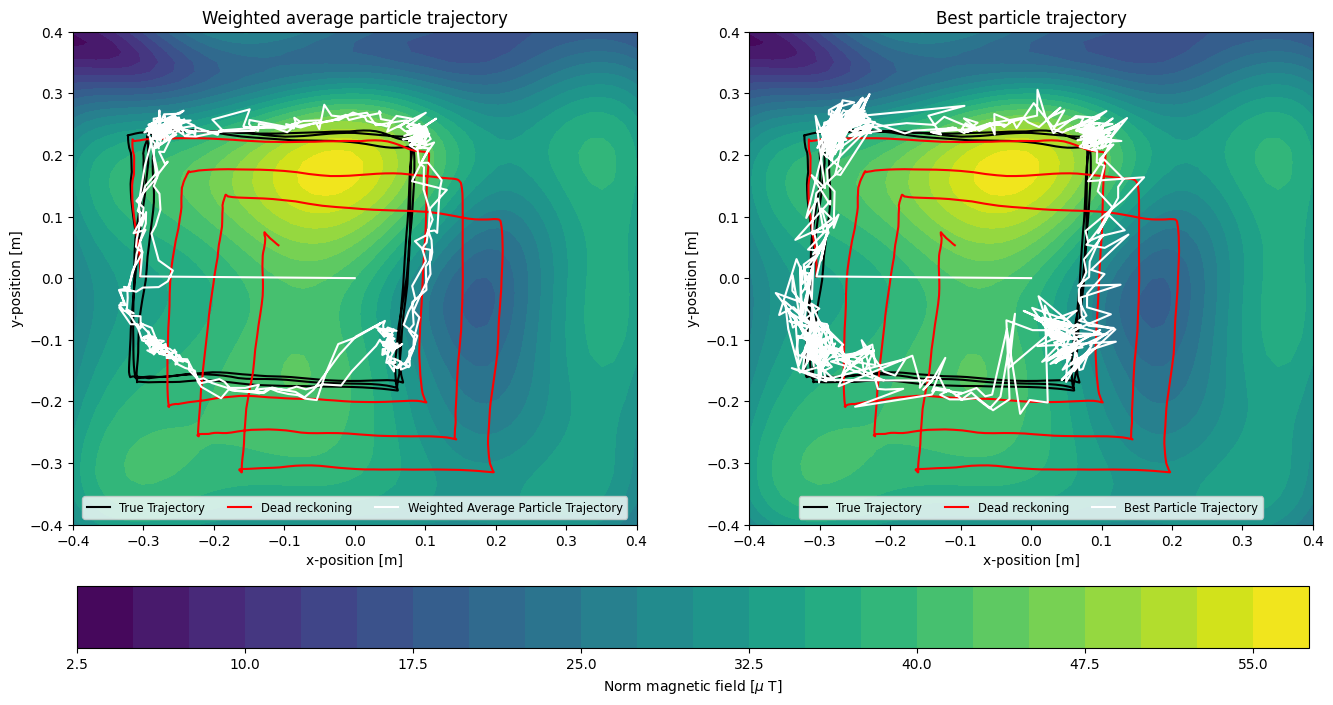

In [17]:
helper.makeParticleFilterPlots(deadReckoning, meanParticlePosition, bestParticlePosition, modelParameters)

#### Discuss

Elaborate on the two plots.
- Does the particle filter improve the position estimates?
- Are the weighted average particle trajectory and the best particle trajectory the same or different? Why is that the case?


1) The particle filter (with the given parameters) greatly improves the position estimate over the dead reckoning; there is no drift, and it follows the true trajectory. However, the particle filter is by no means perfect, as we see it being quite "fuzzy", i.e. still showing a high uncertainty around the trajectory.

2) The weighted average particle trajectory and the best particle trajectory are not exactly the same (we can see this for instance in the bottom right corner of the trajectory). However, they are very similar; this means that there is probably only one particle which has a high weight (the "best" particle), which also is the one that dominates the weighted average plot.


#### Task

Play around with different parameters. Comment on what happens if we choose lower or higher values for
- `initalPositionCovariance`?
- `Nparticles`?
- `processCovariance`?
- `measurementCovariance`?

And reason about why this is the case

1) Changing the initial position covariance (and keeping everything else the same) does not change the effectiveness of the particle filter much. This may be because we prescribe the initial position, and the model propagating and updating the measurements have their own mechanicms which do not depend on the initial covariance, hence making this value not the most important in the mechanism of the particle filter.
2) The number of particles greatly influences the system. If we choose a very small amount of particles (such as 10), there is a huge uncertainty in the model, and the square shape of the trajectory can barely be distinguished. Inversely, higher amount of particles (such as 500) improve the quality of the estimation (with no other parameters changed). We also see that there is no longer one particle that has a much larger weight than the others; the higher density of particles smoothes the estimate. However, more particles means more run time (10x the particles --> 10x the run time on my computer); while the number of particles should be high enough, it is costly to go too high.

In [15]:
''' Number of particles used in the particle filter '''
Nparticles = 500


''' Inital position covariance of the position '''
initalPositionCovariance = np.eye(3)*0


''' process covariance and measurement covariance '''
processCovariance = np.eye(3)*0.001*2
measurementCovariance = np.eye(3)*1.5


''' Initialize particle positions '''
particlePositions = np.ones((3, Nparticles))*magnetometerInitialPosition


''' Create matrices to store mean and best particle position at every time-step'''
meanParticlePosition = np.zeros((3, modelParameters['NtimeSteps']))
bestParticlePosition = np.zeros((3, modelParameters['NtimeSteps']))


''' Initialize and run  the Particle Filter '''
modelParameters['NtimeStepPF'] = 0
for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosPF = deltaMagnetometerPositions[:, timendx+1]
    ymeasPF = magnetometerMeasurements[:, timendx+1]
    (particlePositions, 
     meanParticlePosition[:, timendx+1], 
     bestParticlePosition[:, timendx+1]) = particleFilter(particlePositions, 
                                                          deltaPosPF, 
                                                          ymeasPF, 
                                                          processCovariance, 
                                                          measurementCovariance, 
                                                          Nparticles,
                                                          modelParameters)

    modelParameters['NtimeStepPF'] += 1


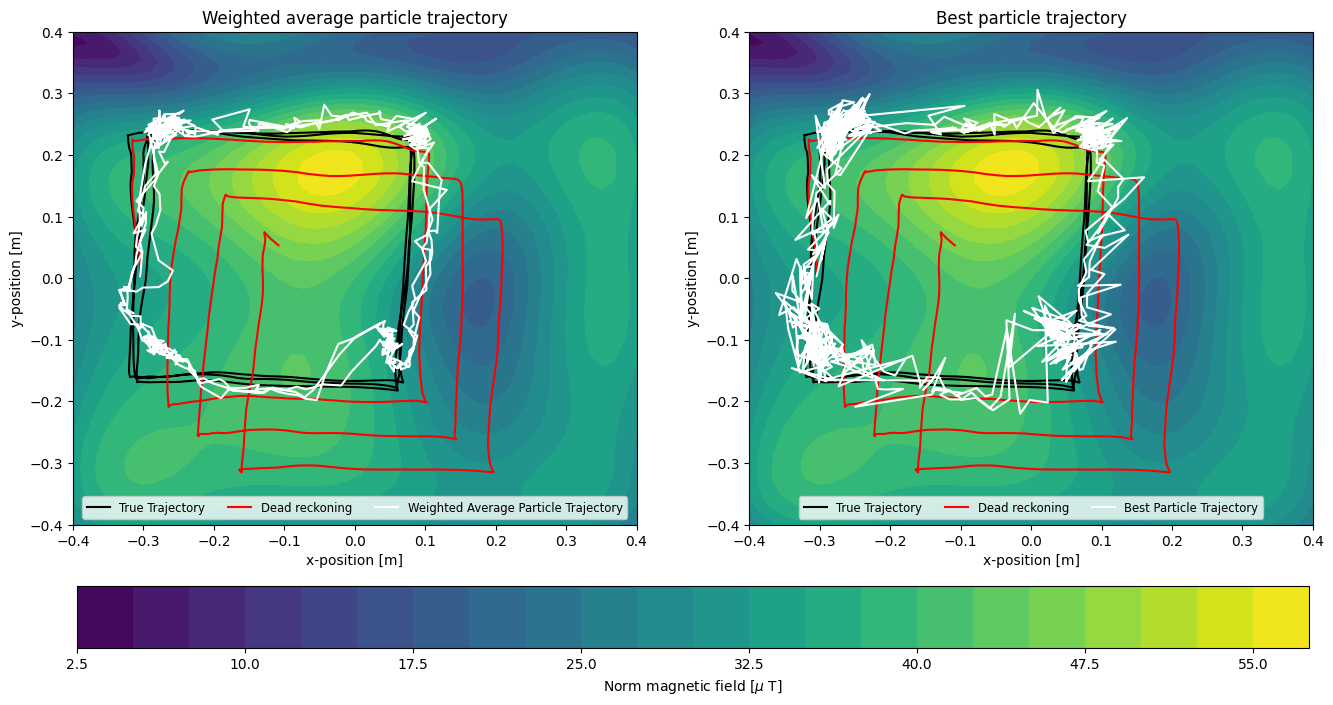

In [16]:
helper.makeParticleFilterPlots(deadReckoning, meanParticlePosition[:, 1:], bestParticlePosition[:, 1:], modelParameters)

#### Discuss

Comment on the reason for choosing a particle filter for this estimation problem.

While, the process dynamics are linear, the measurement model, $\mathbf{y}_t = \mathbf{f(p)}_t + \mathbf{v}_t$, is highly non-linear. Magnetic field maps, especially of indoor environments are complex and nonuniform, and often have multiple locations with similar field strengths. Implicity this means we can not use a Kalman Filter, for such a problem. Furthermore, using an Extended Kalman Filter, which is able to handle non-linearitie, is still not ideal. It relies on the Jacobian to linearize the measurment model. Because, the magnetic map $f(\mathbf(p)_t)$ is highly irregular, this linearization is a poor approximation of the global nonlinearities of the magnetic map. Moreover, the EKF forces the posterior to remain a single Gaussian distribution, and in a multi-modal environment with multiple peaks (instead of one like in Gaussian) this may potentially lead to divergence. As such, while running a EKF would work, it would fail to caputure the multi-modal magnetic map, potentially leading to accumulating errors. There are similar limitations when considering the Unscented Kalman Filter (UKF), which generally handles more non-linear behavioure better than the EKF, as it is still restricted to a Gaussian posterior. Conversely Particle Filter doesn't use any assumption, it handles the non-linearities of the dynamic and measurement models by directly sampling the state space (particles). This will lead to much more accurate estimates, although at a higher computational cost.